In [15]:
'''
This code will display plots directly, and make .gif files based on the output of simulations.
The input to both these functions must be a timestamp string. The string is displayed when calling the .log() method of the simulate class, after calling the .run() method.
'''

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import animation
import os

In [ ]:
## parameters ##
timestamp = '2026-05-28--12_47_58'
solution_types = ['C', 'Cp', 'Ch']
interval = 100
plots = False
gifs = True
show_figs = False

In [27]:
def make_plots(timestamp, solution_types, show_figs):
    timestep_vals = np.load(f'../data/plots/{timestamp}/timestep_vals.npy')
    # print(timestep_vals)
    xx = np.load(f'../data/plots/{timestamp}/xx.npy')
    zz = np.load(f'../data/plots/{timestamp}/zz.npy')
    if not os.path.isdir(f'../data/figures/{timestamp}/'):
        os.mkdir(f'../data/figures/{timestamp}/')
    for soln_type in solution_types:
        fname = f'../data/plots/{timestamp}/{soln_type}_plots.npy'
        plots = np.load(fname)
        for i in np.arange(len(plots[0,0])):
            plot = plots[:,:,i]
            t = round(timestep_vals[i],3)
            fig, ax = plt.subplots()
            scat = ax.pcolor(xx,zz,plot)
            cbar = plt.colorbar(scat)
            cbar.set_label('concentration')
            ax.set_title(f'{soln_type} t = {t}')
            plt.savefig(f'../data/figures/{timestamp}/{soln_type}_{i}.png', format='png')
            if show_figs:
                plt.show()

def make_gifs(timestamp, solution_types, interval):
    timestep_vals = np.load(f'../data/plots/{timestamp}/timestep_vals.npy')
    xx = np.load(f'../data/plots/{timestamp}/xx.npy')
    zz = np.load(f'../data/plots/{timestamp}/zz.npy')
    for soln_type in solution_types:
        fname = f'../data/plots/{timestamp}/{soln_type}_plots.npy'
        plots = np.load(fname)
        fig, ax = plt.subplots()
        scat = ax.pcolor(xx,zz,plots[:,:,0])
        cbar = plt.colorbar(scat)
        cbar.set_label('concentration')
        ax.set_xlabel('[m]')
        ax.set_ylabel('[m]')

        def update(frame):
            scat.set_array(plots[:,:,frame])
            ax.set_title(f'{soln_type}: t = {round(timestep_vals[frame],3)}')
            return scat

        ani = animation.FuncAnimation(fig=fig, func=update, frames=len(timestep_vals), interval=interval)
        ani.save(f'../data/gifs/{timestamp}_{soln_type}.gif')

C:\Users\sedox\AppData\Local\Temp\ipykernel_71484\2301156604.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.


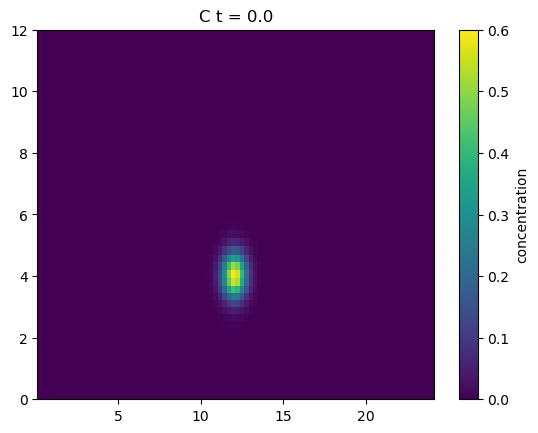

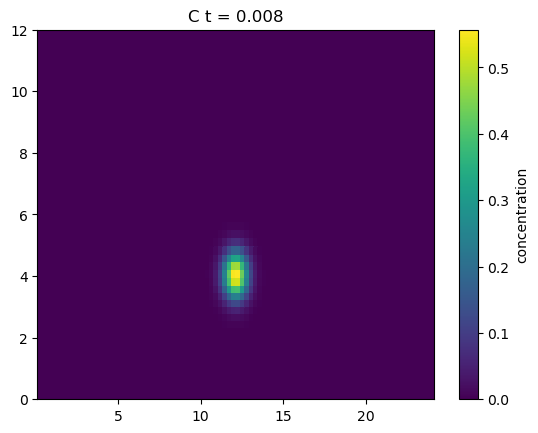

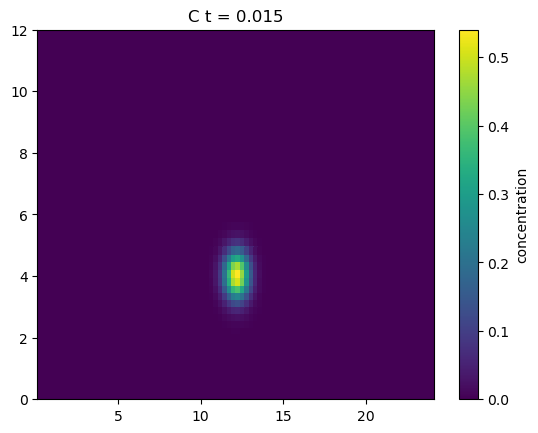

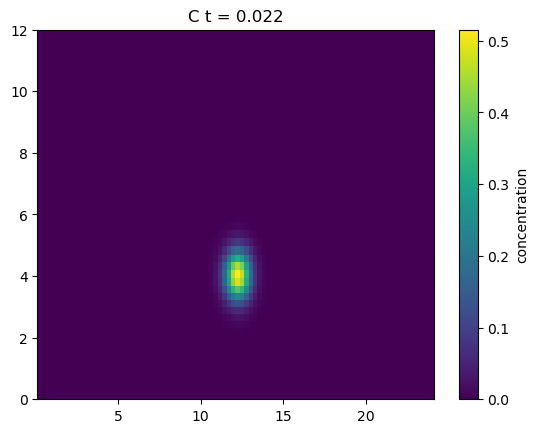

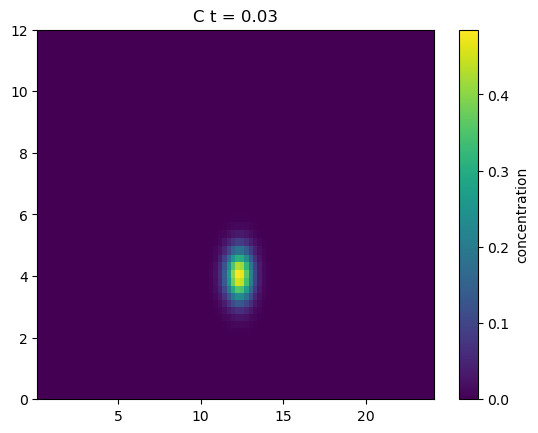

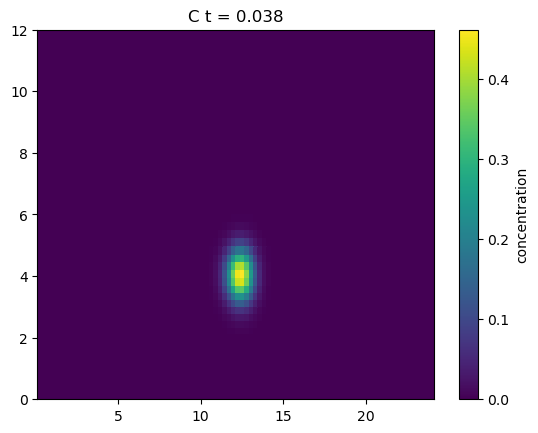

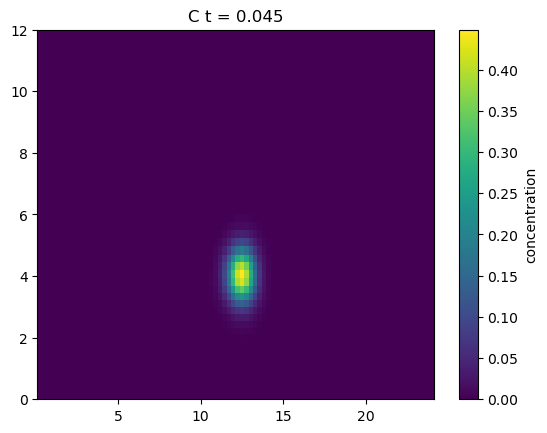

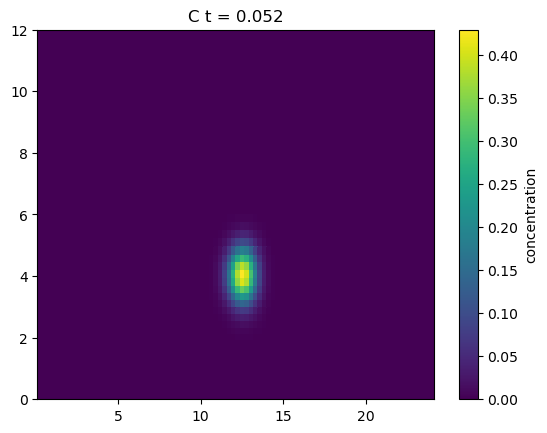

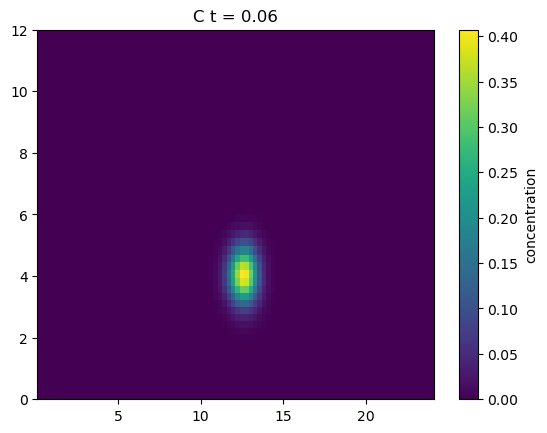

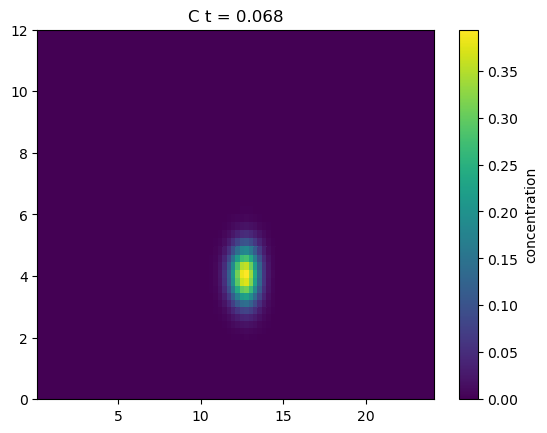

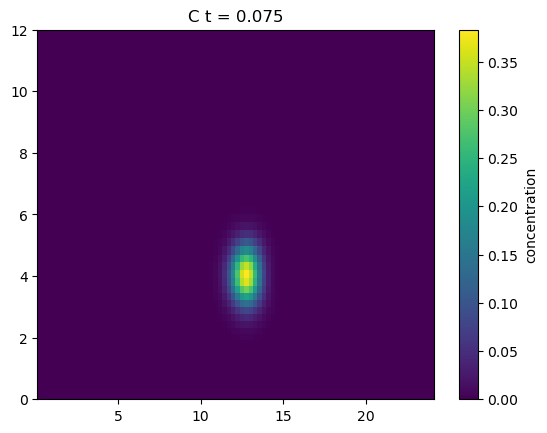

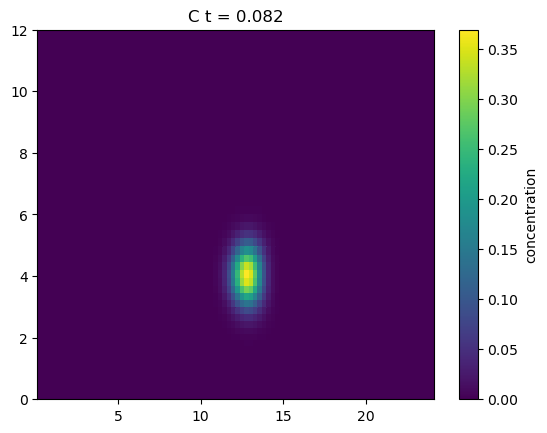

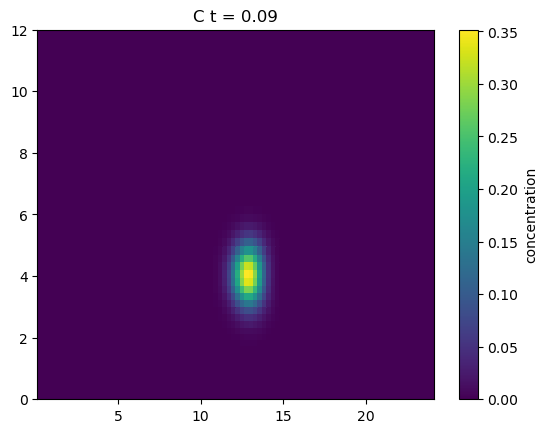

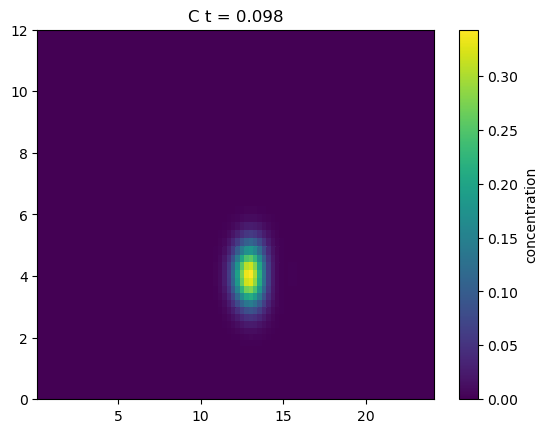

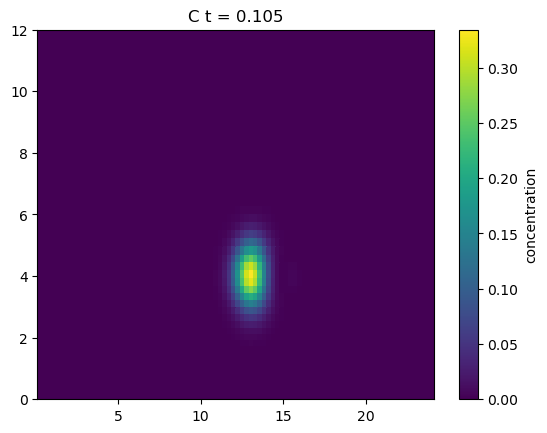

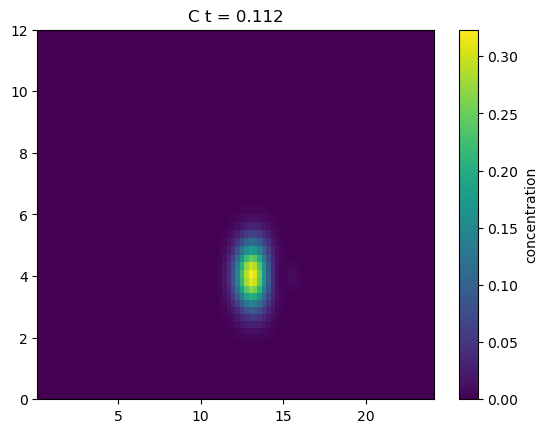

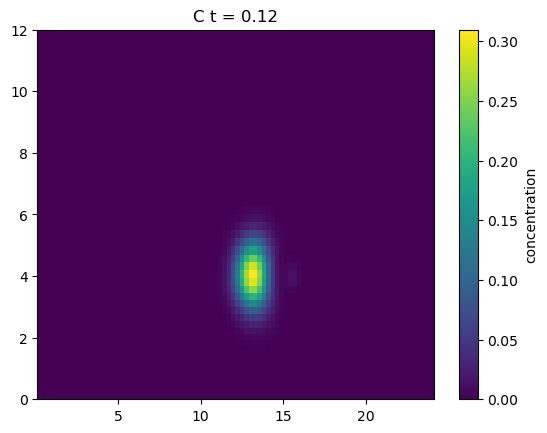

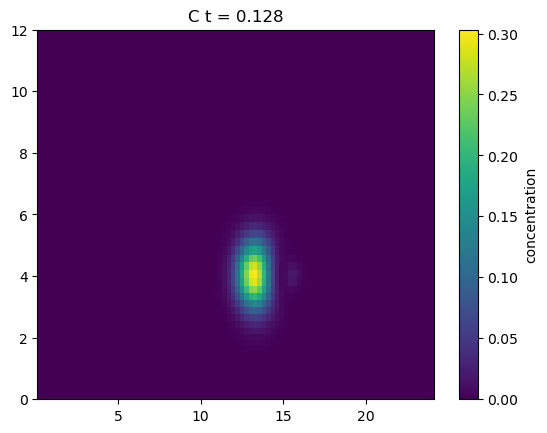

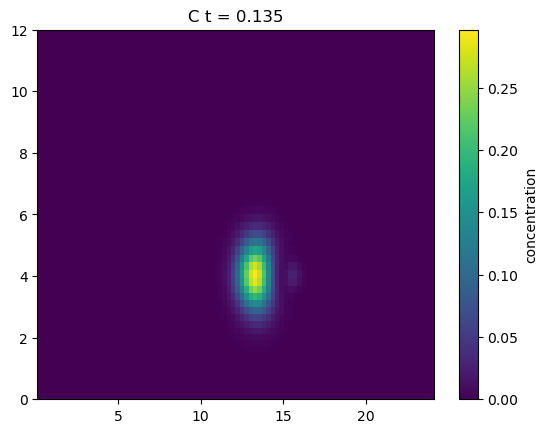

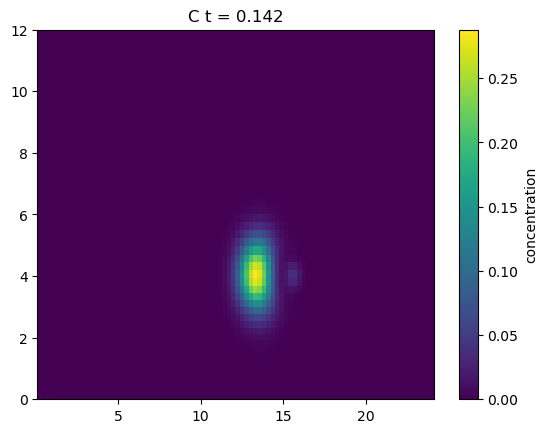

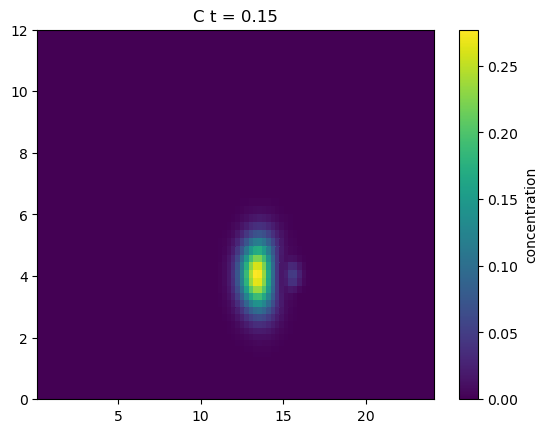

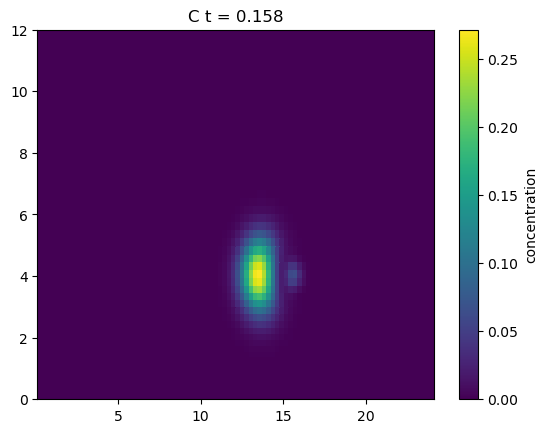

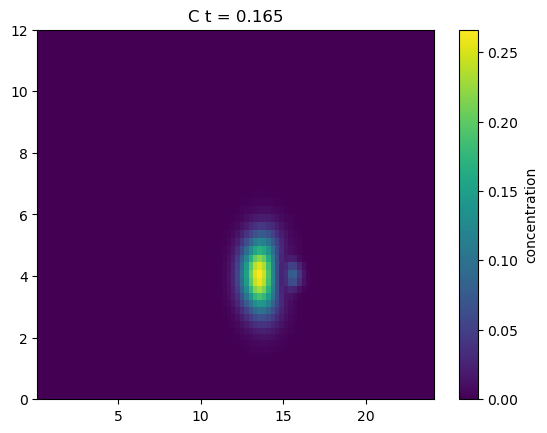

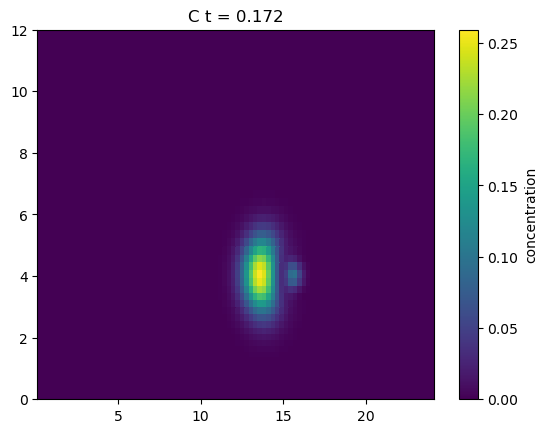

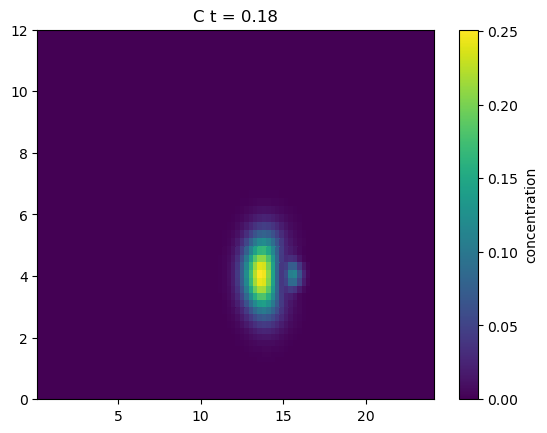

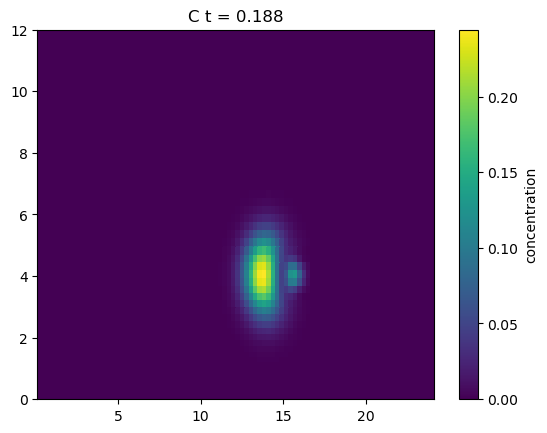

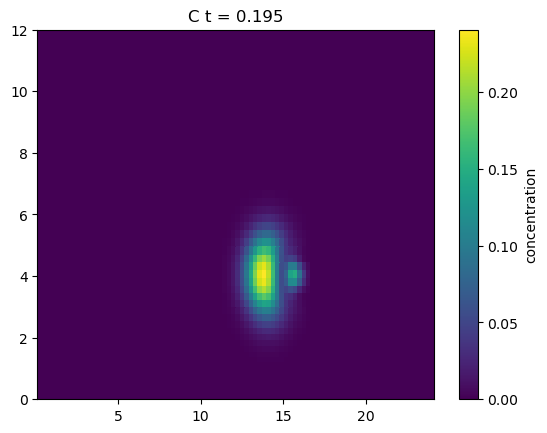

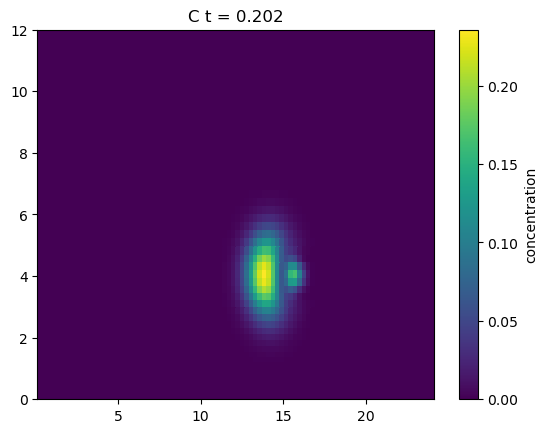

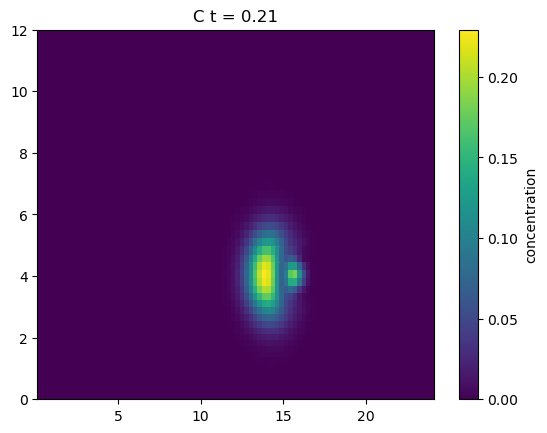

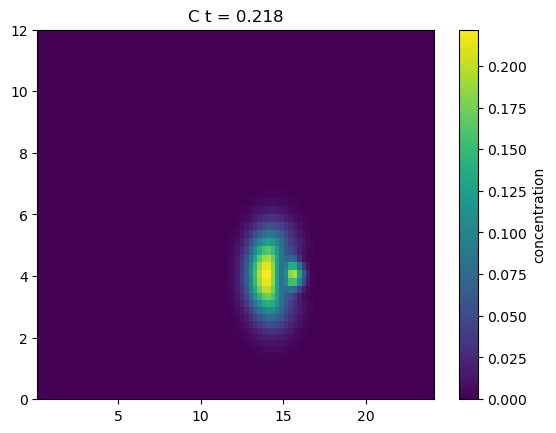

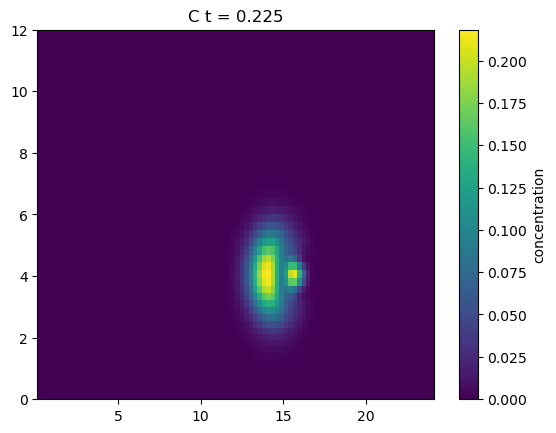

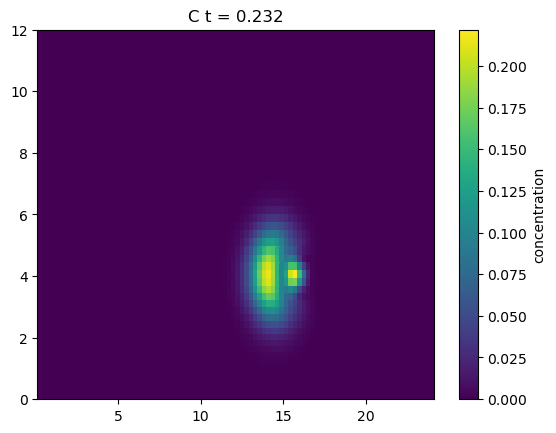

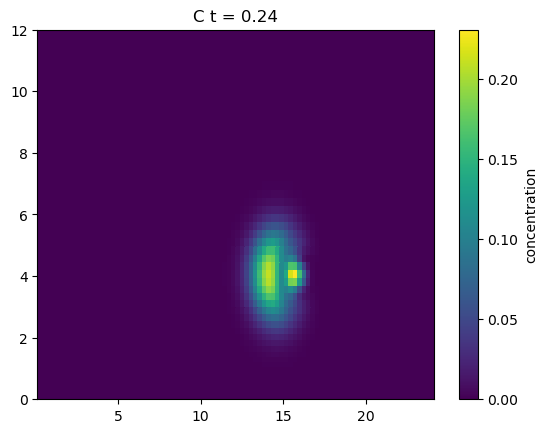

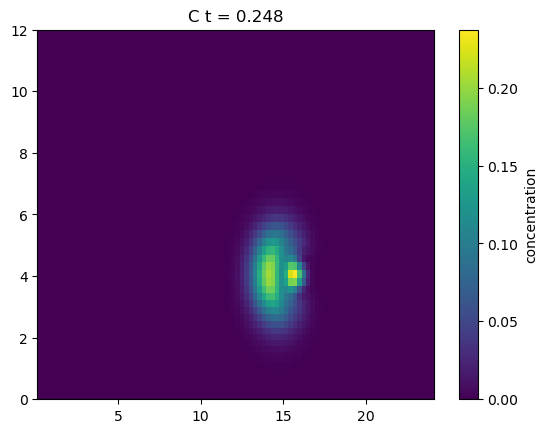

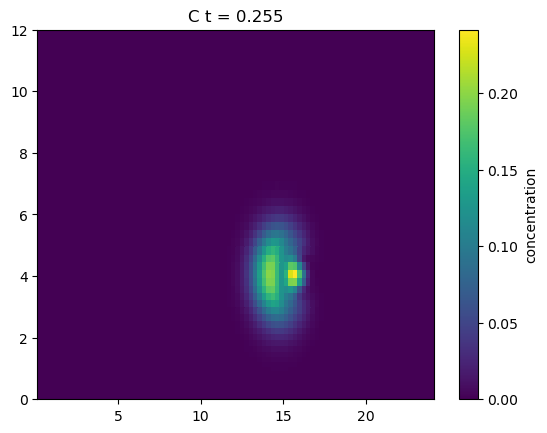

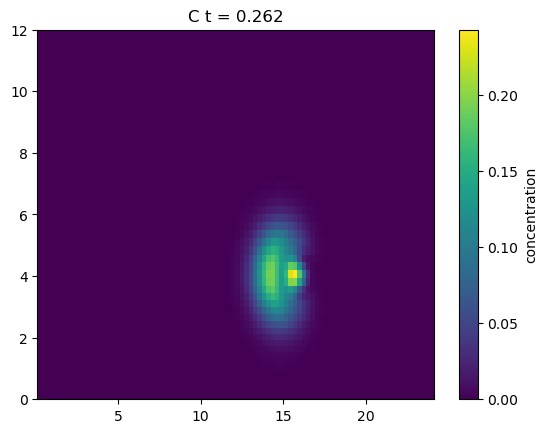

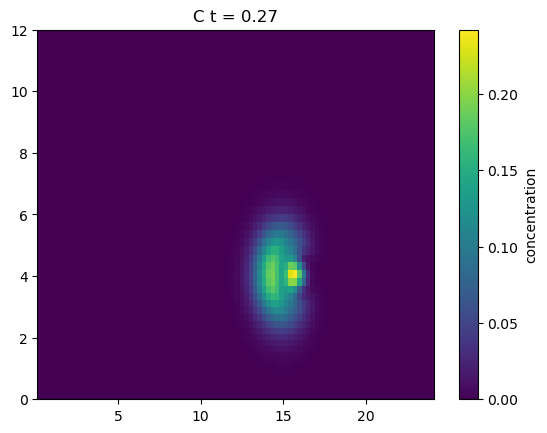

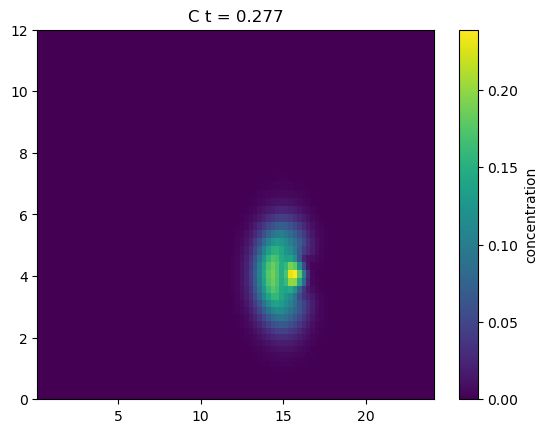

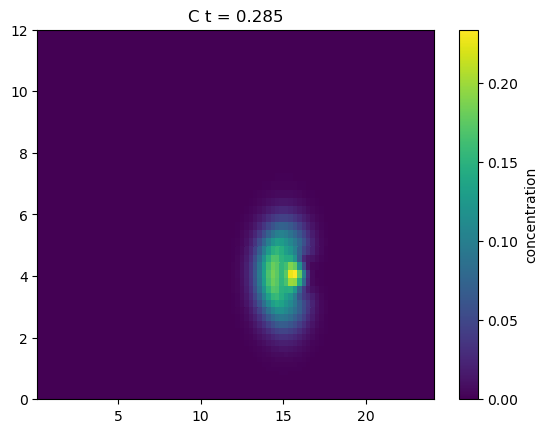

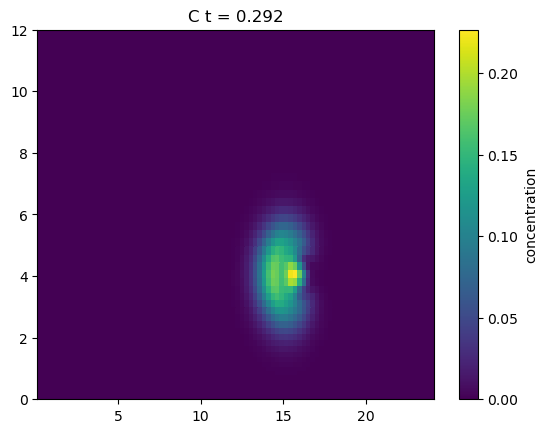

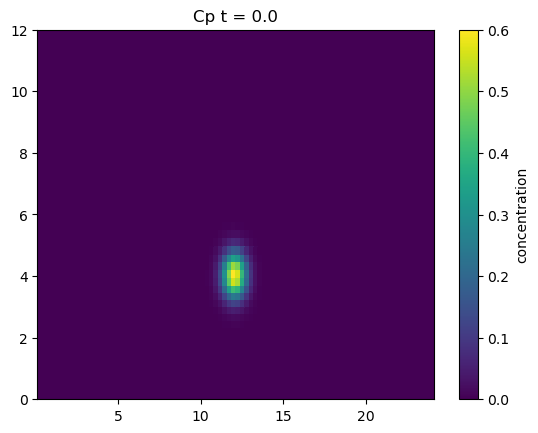

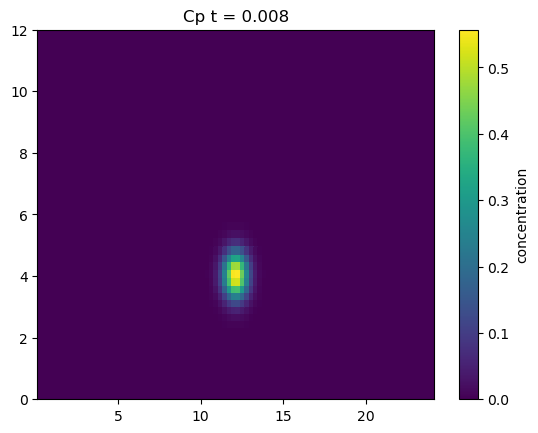

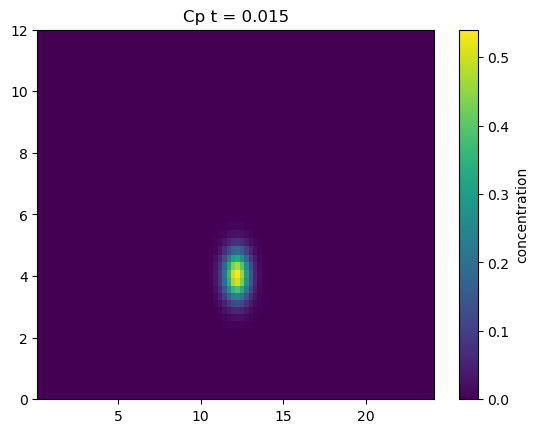

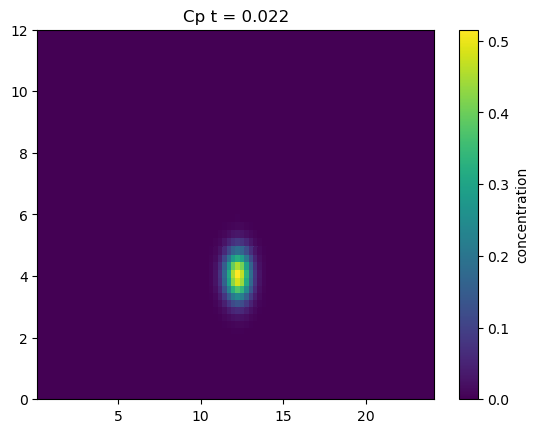

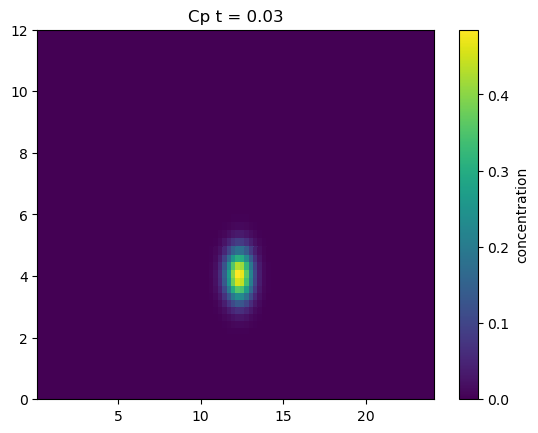

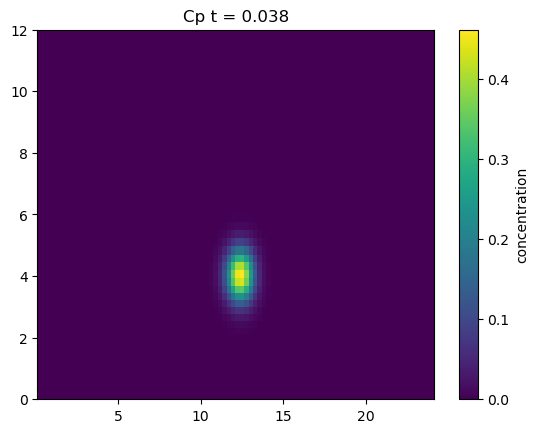

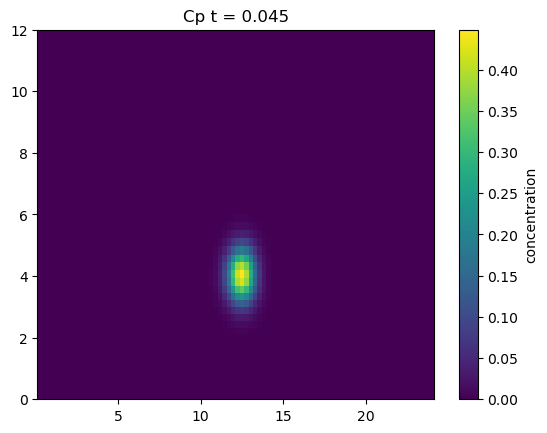

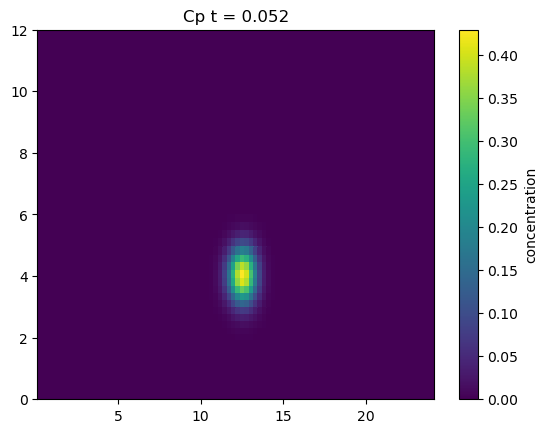

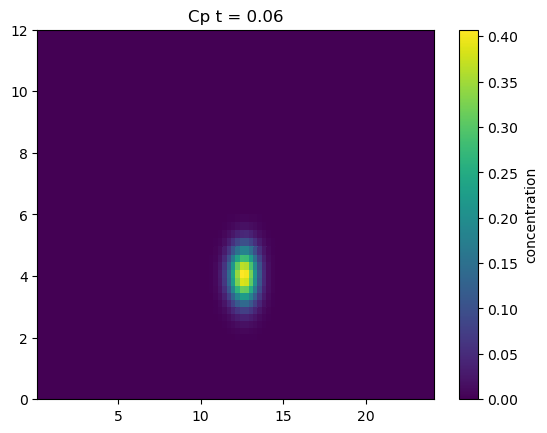

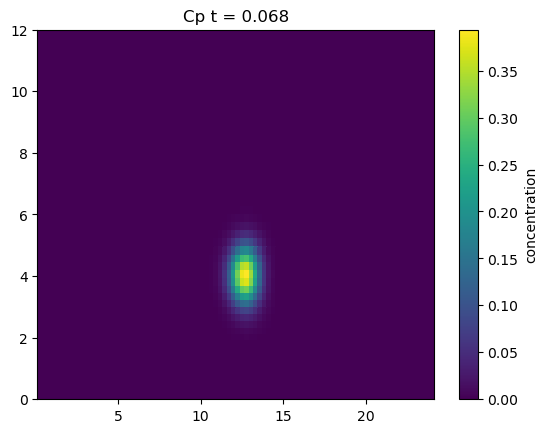

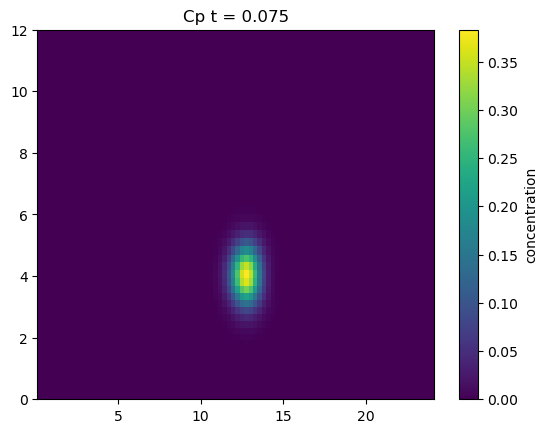

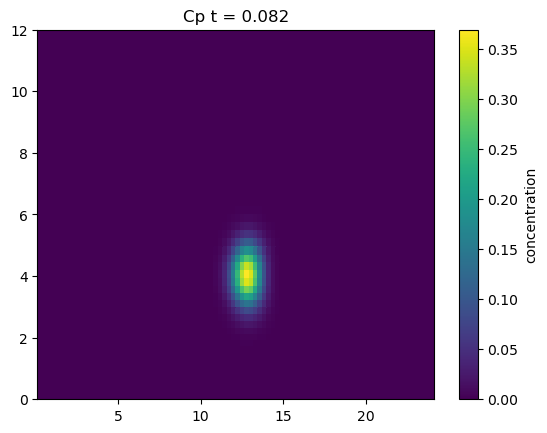

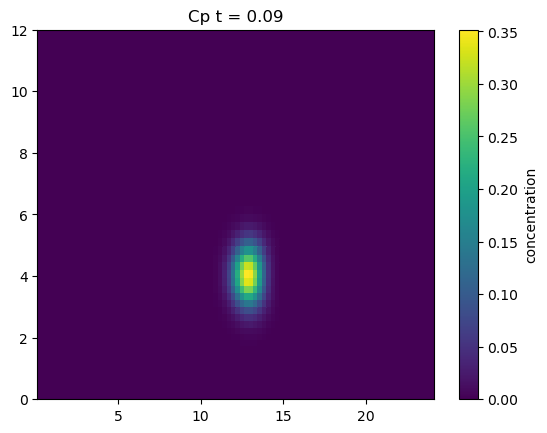

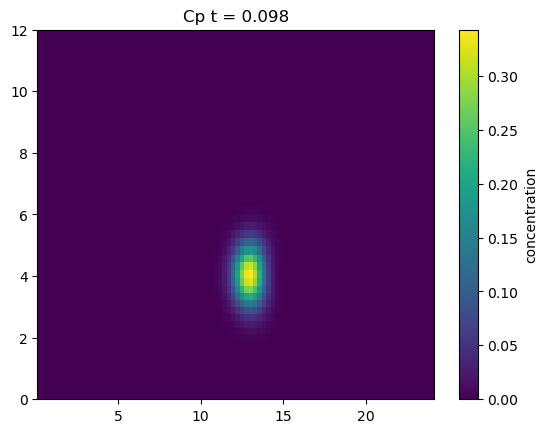

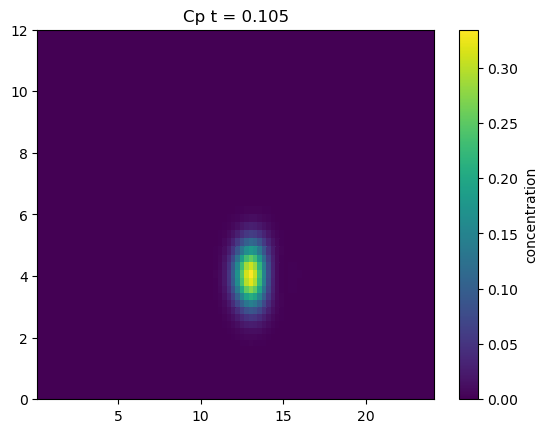

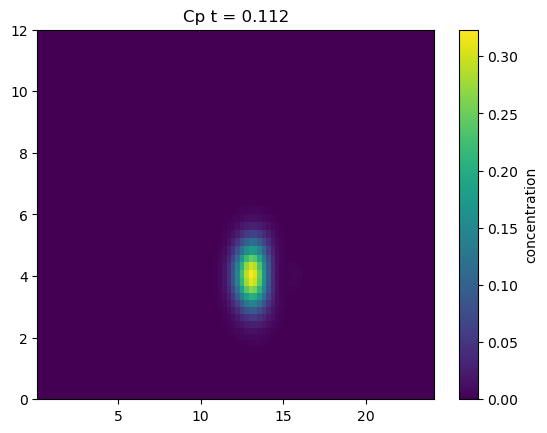

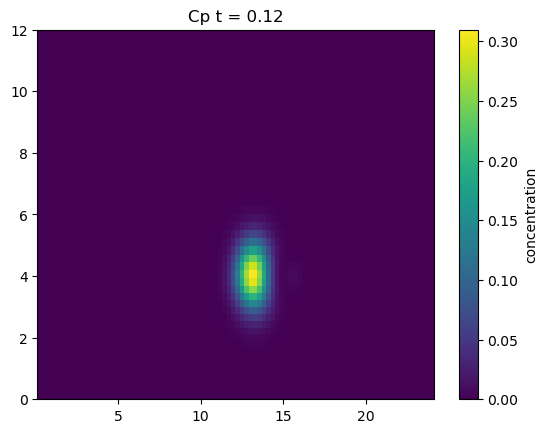

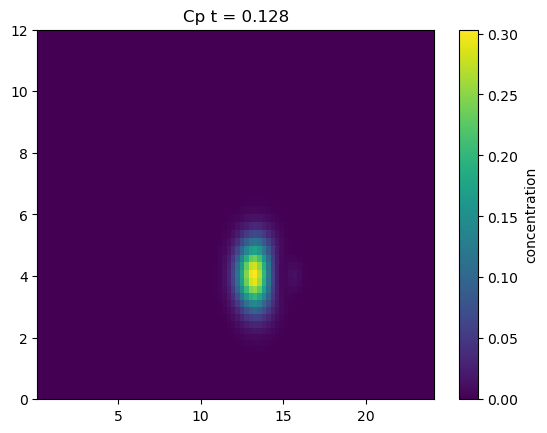

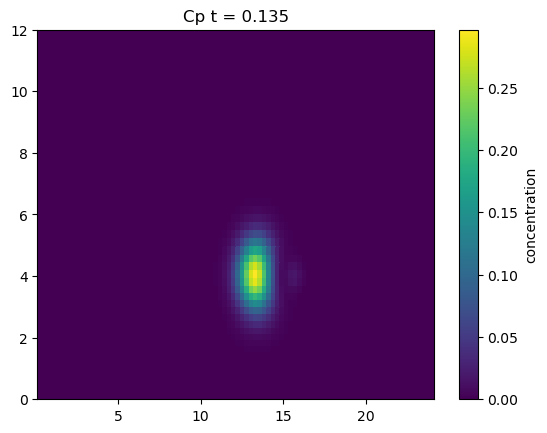

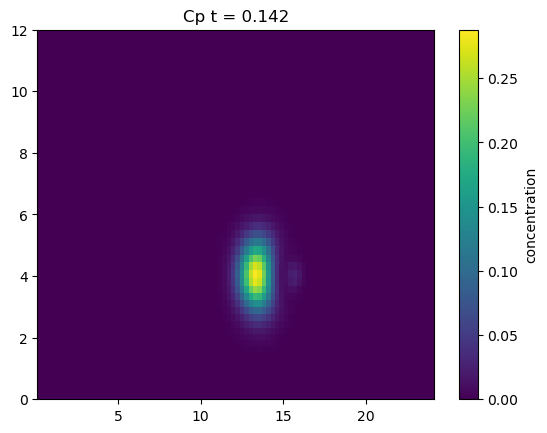

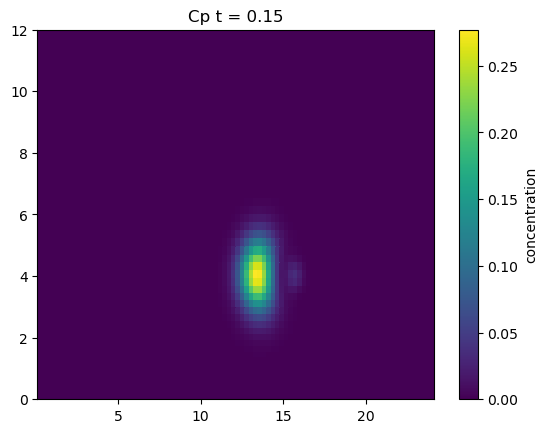

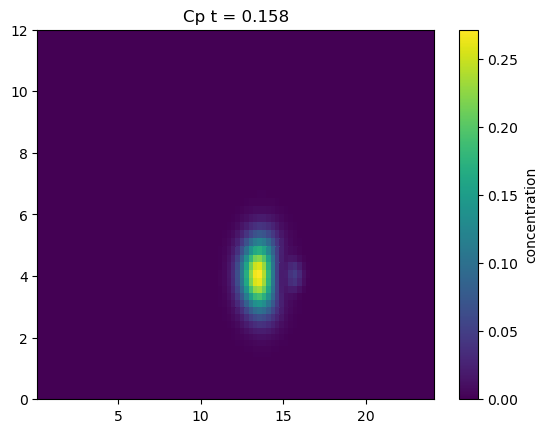

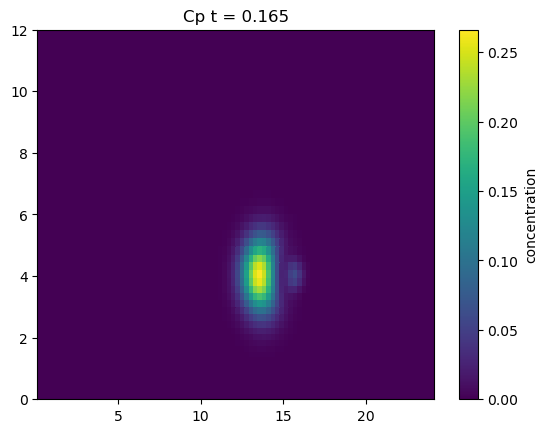

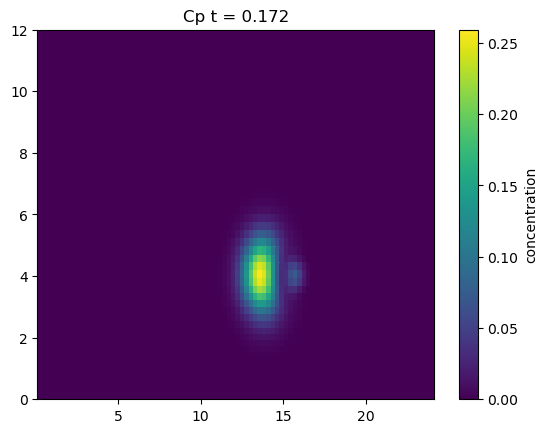

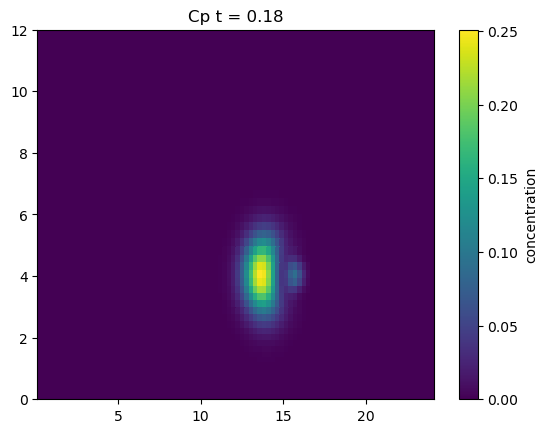

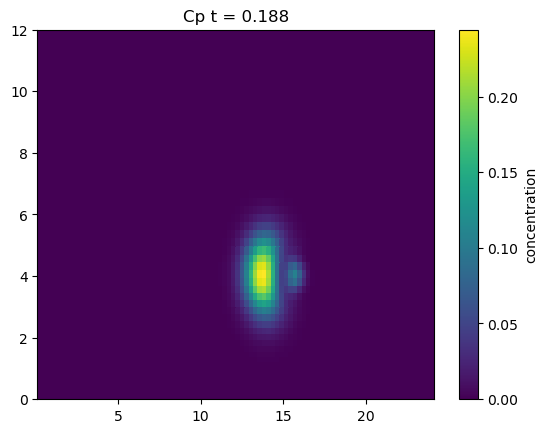

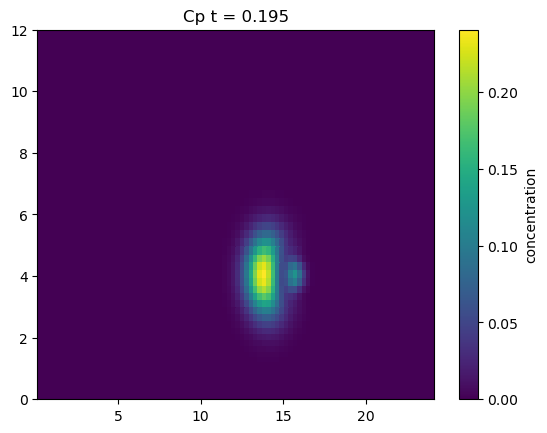

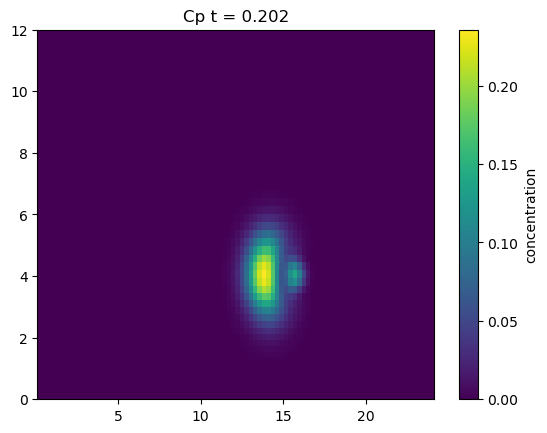

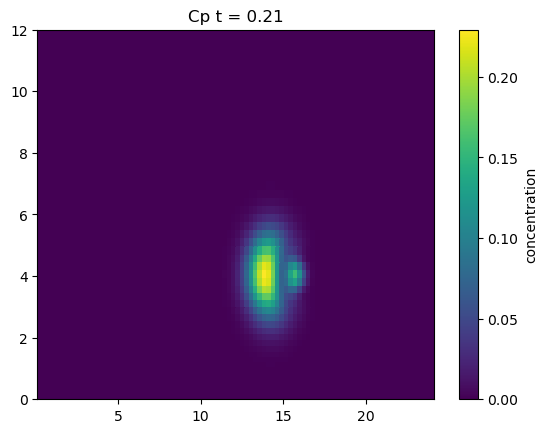

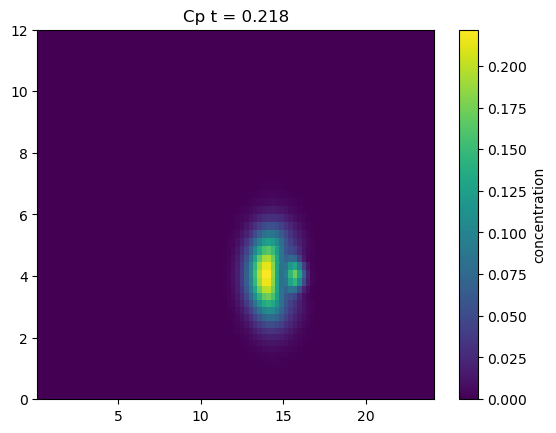

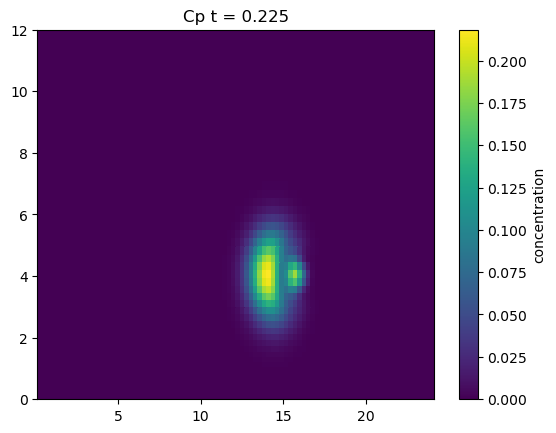

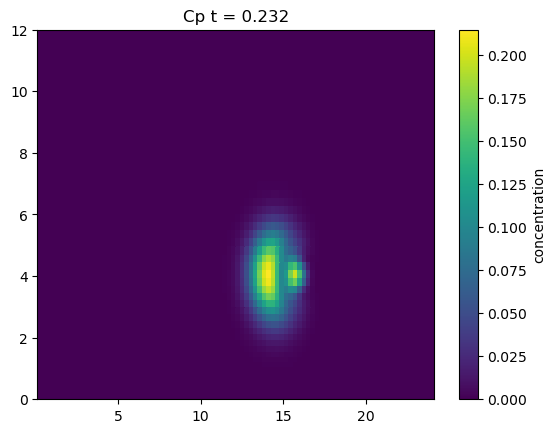

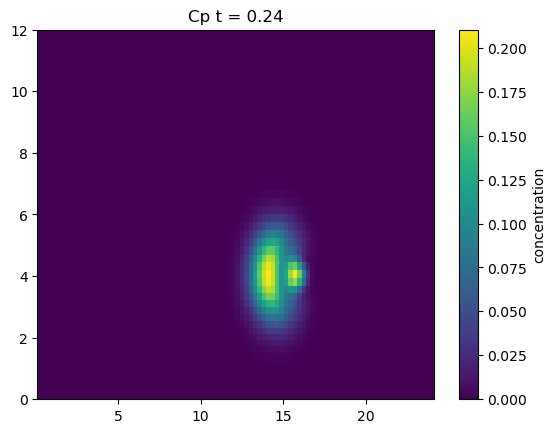

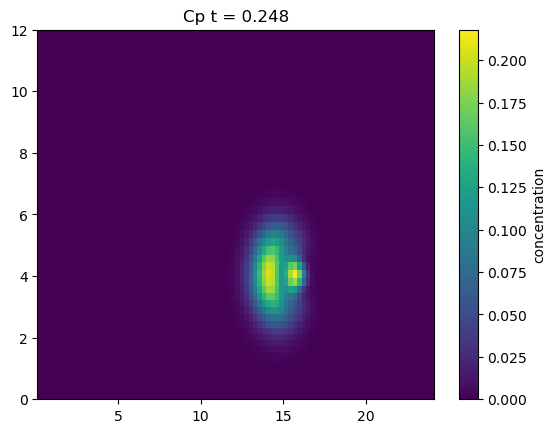

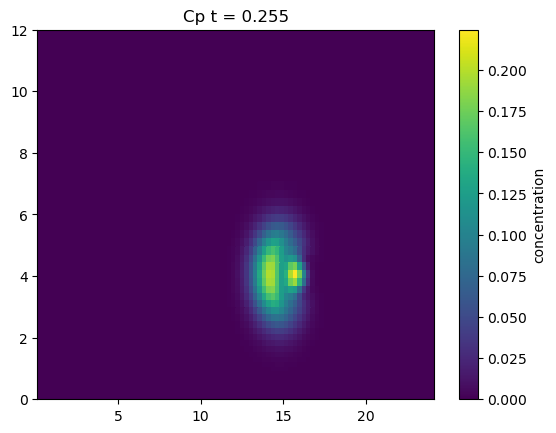

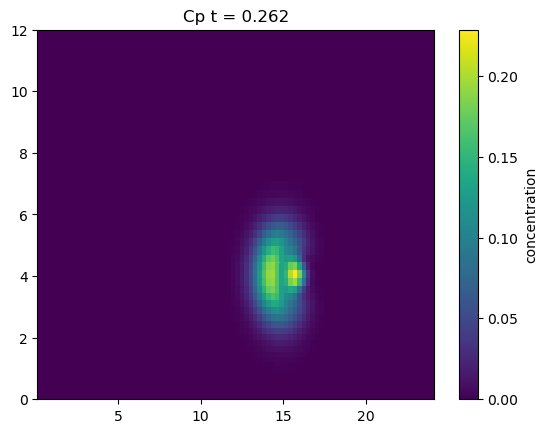

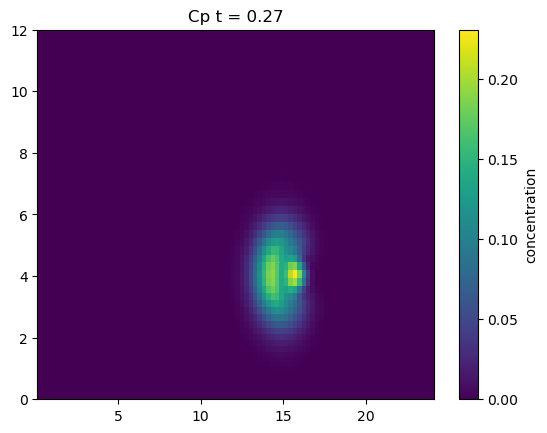

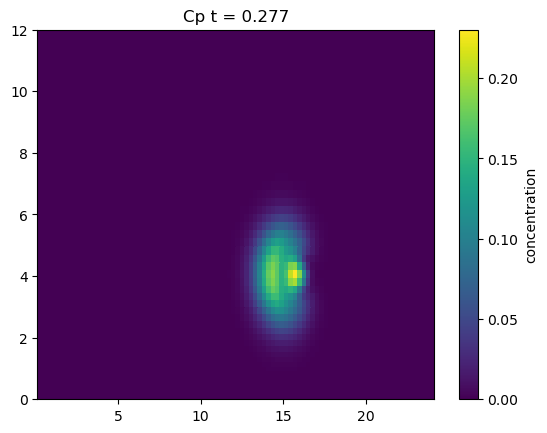

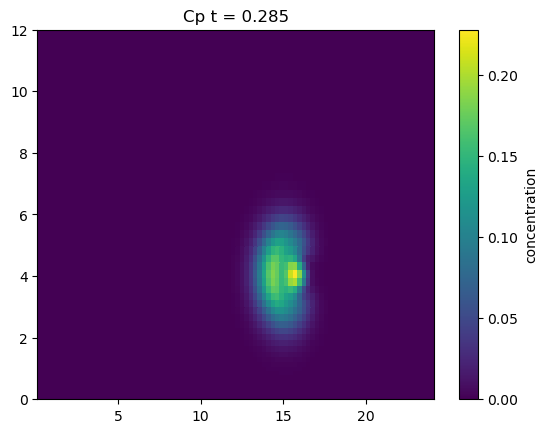

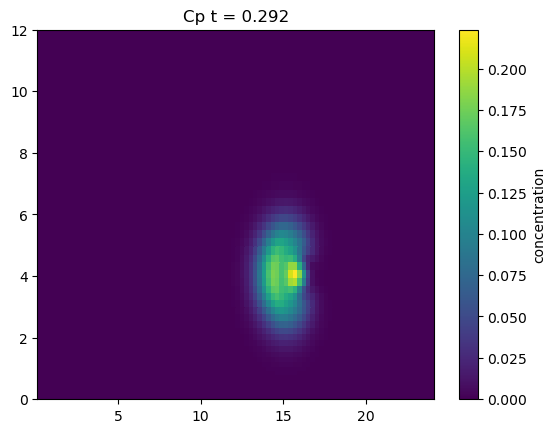

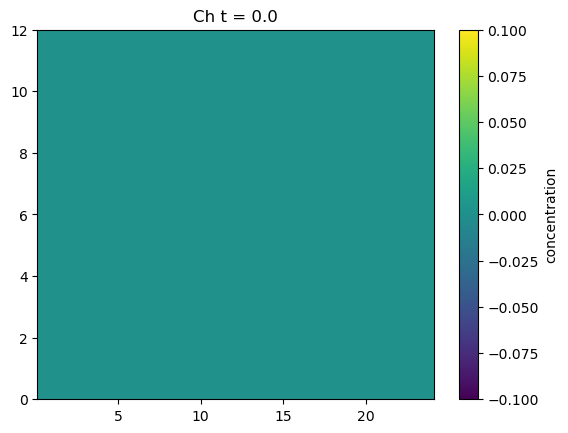

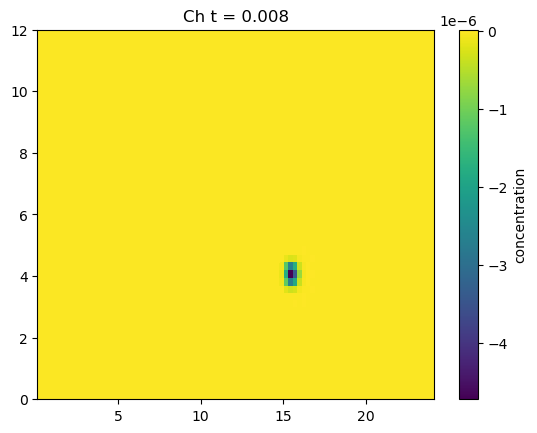

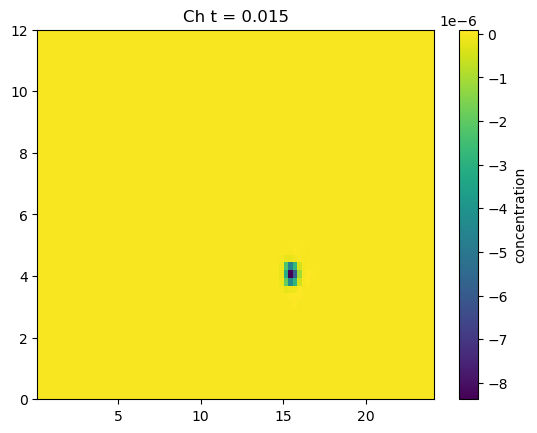

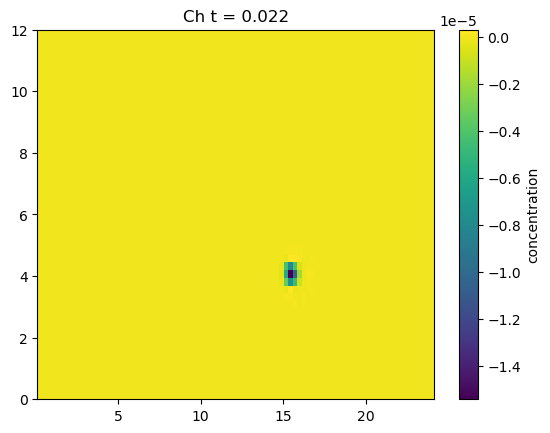

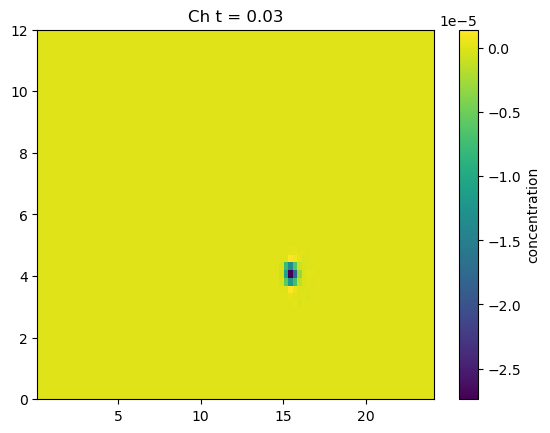

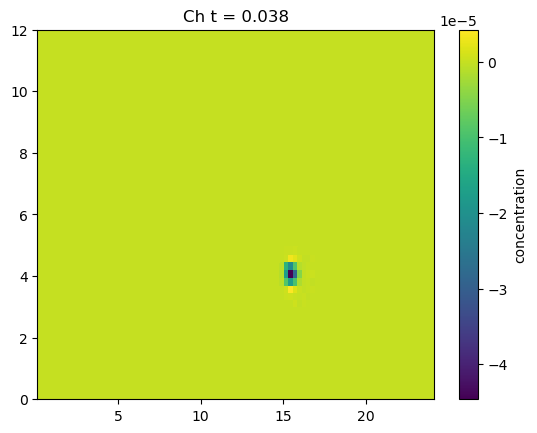

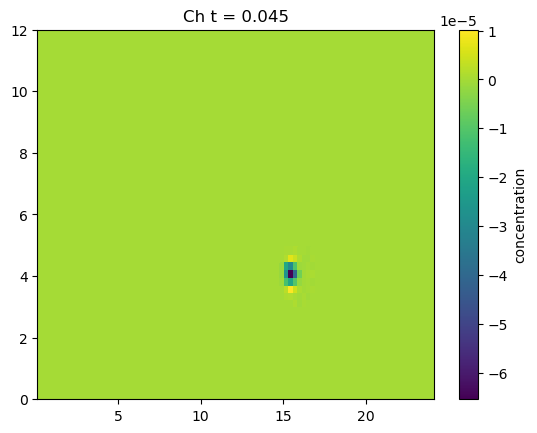

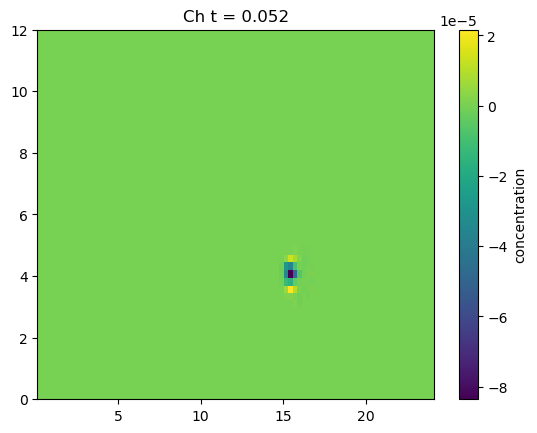

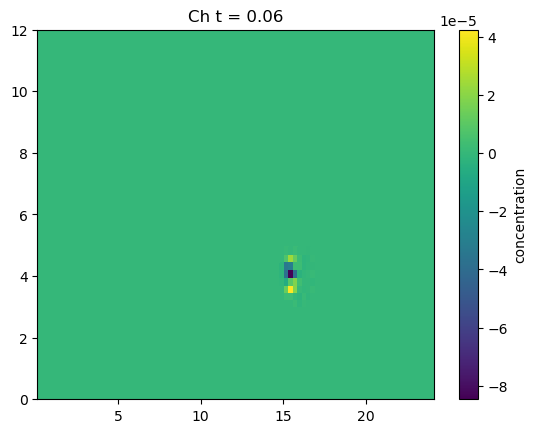

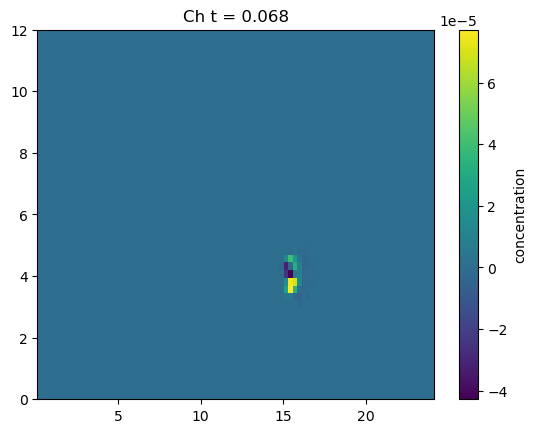

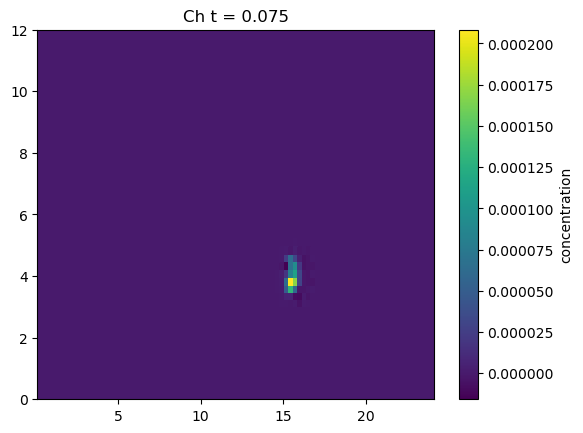

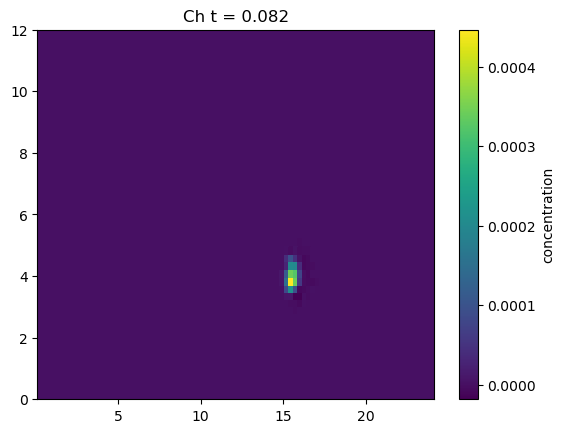

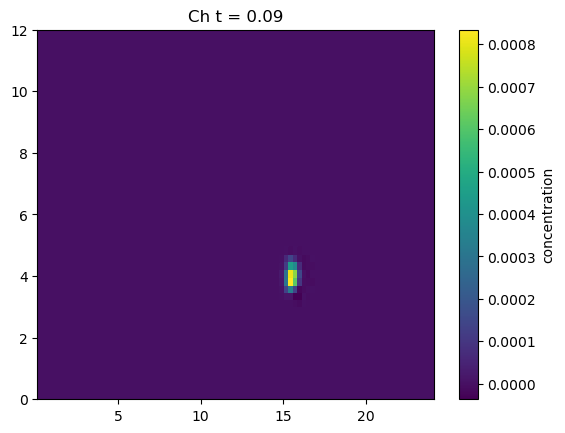

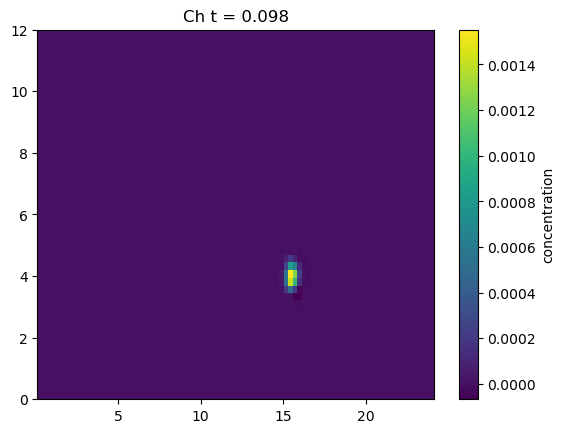

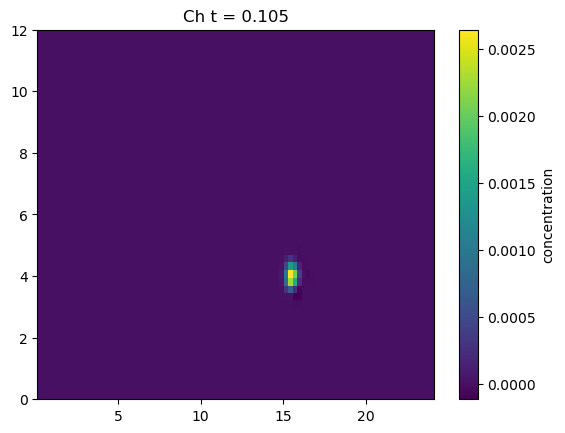

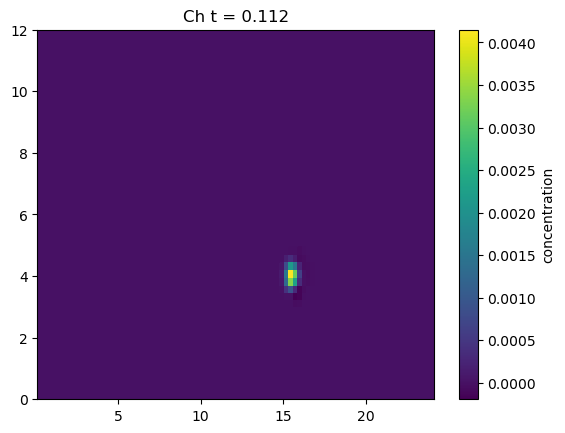

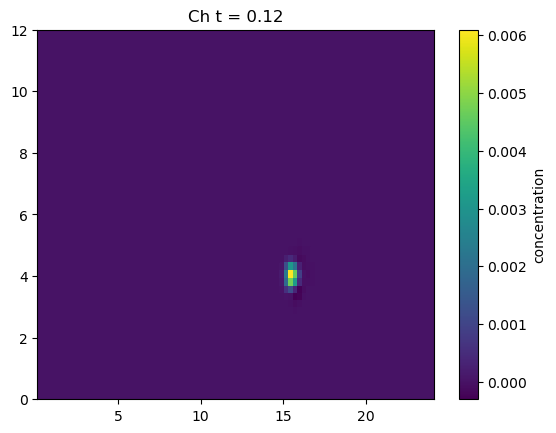

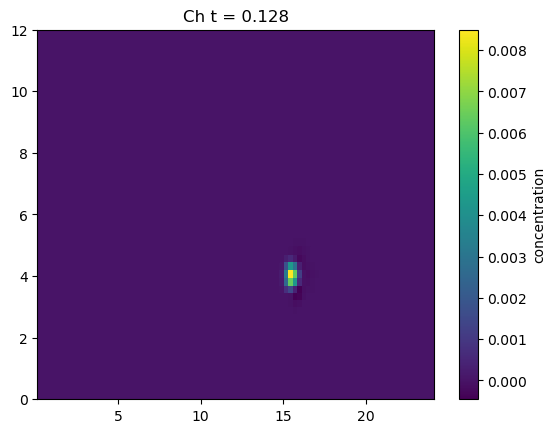

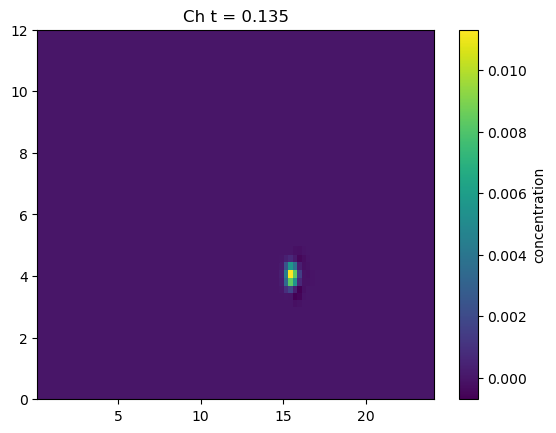

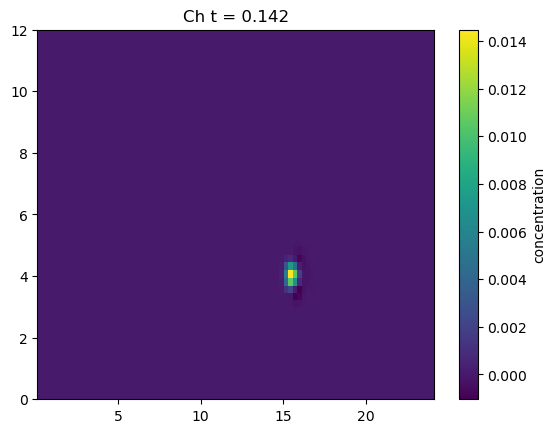

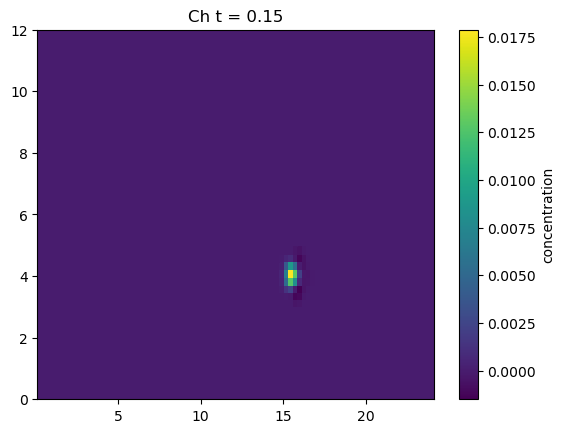

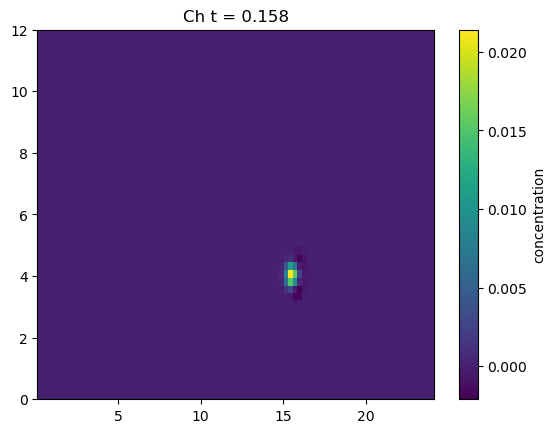

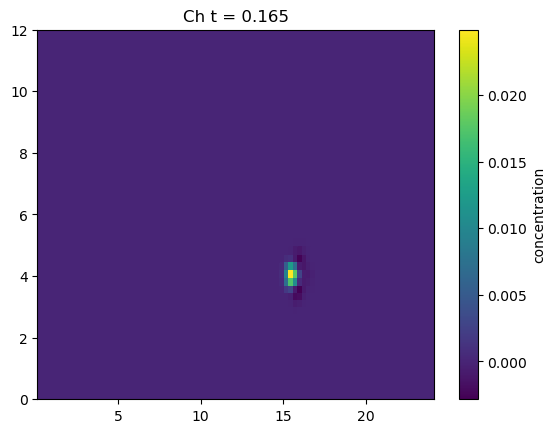

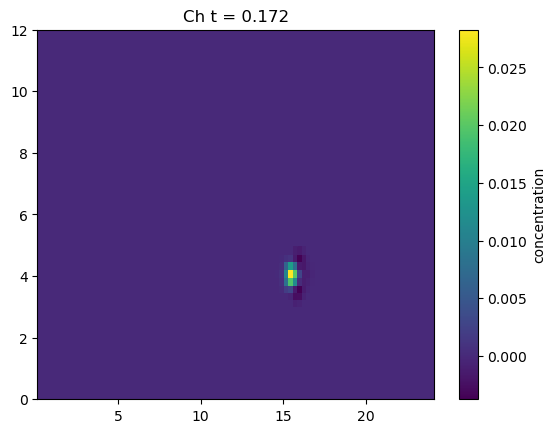

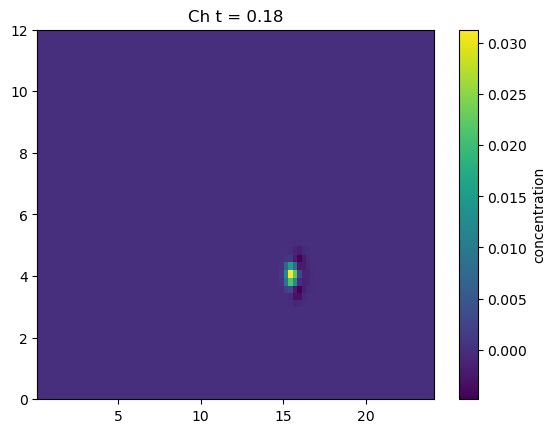

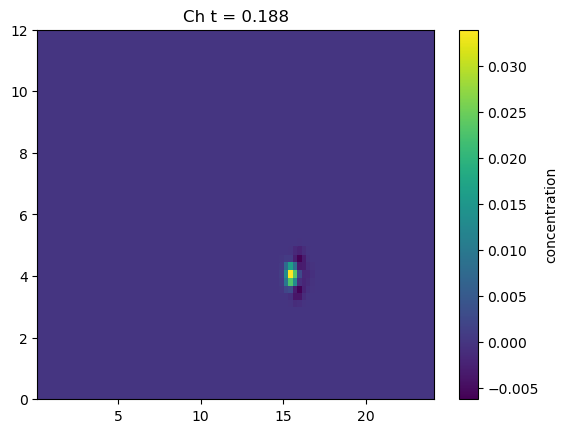

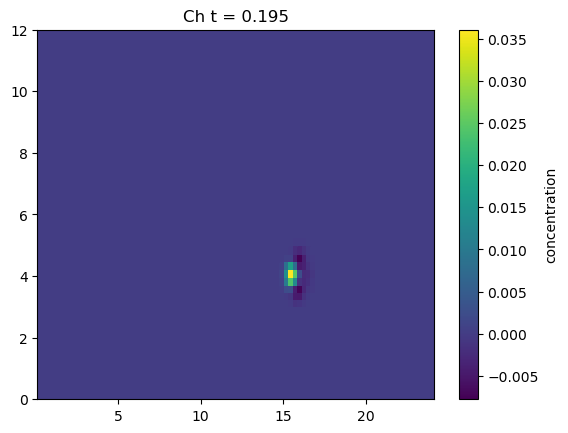

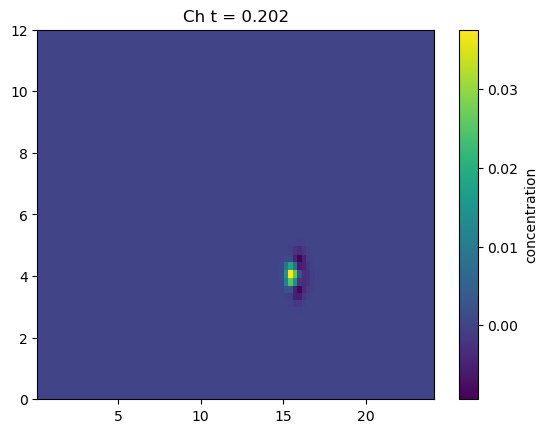

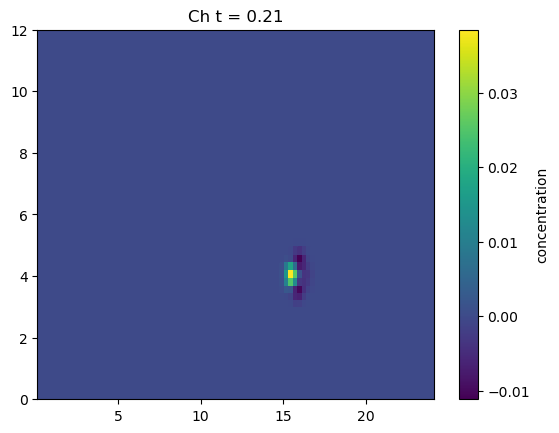

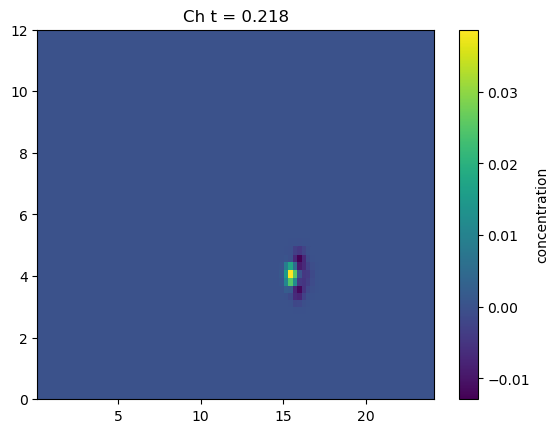

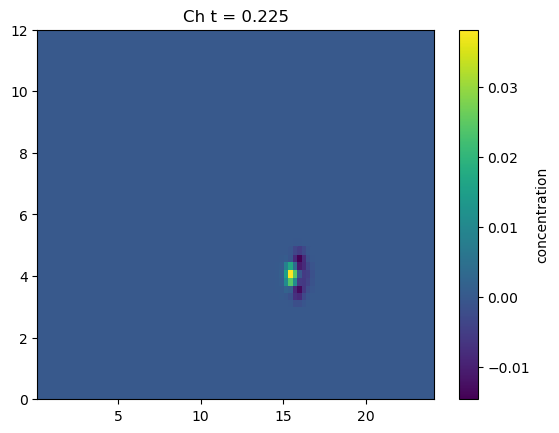

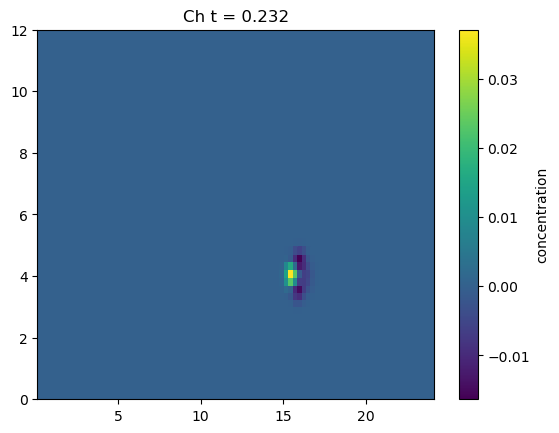

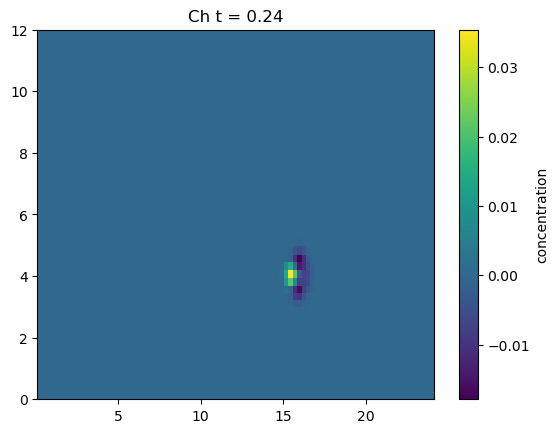

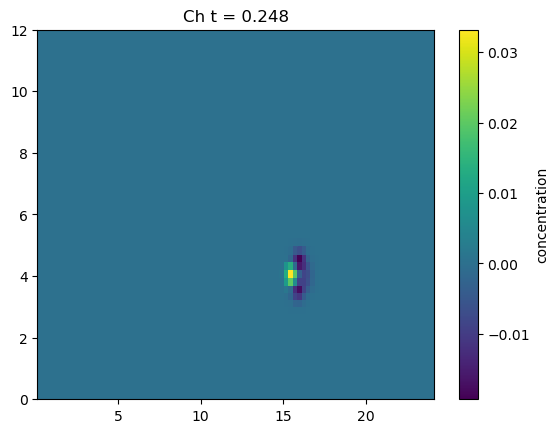

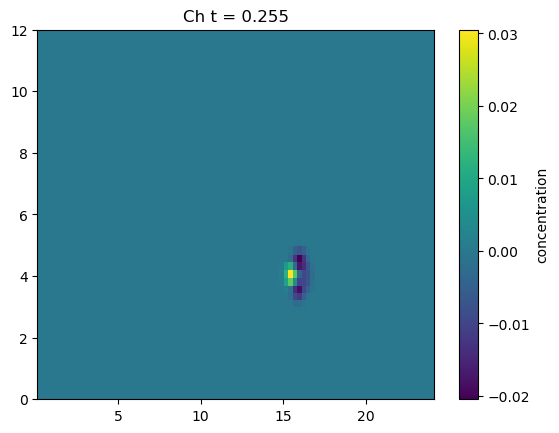

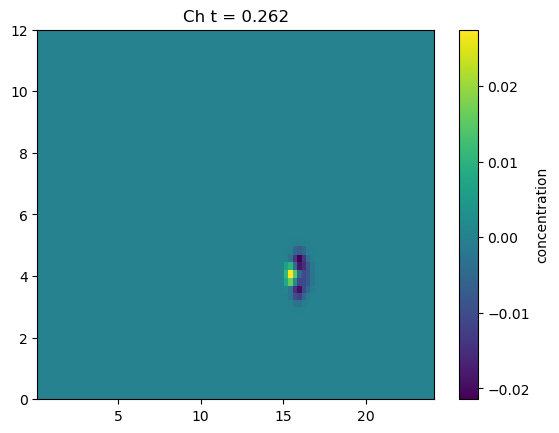

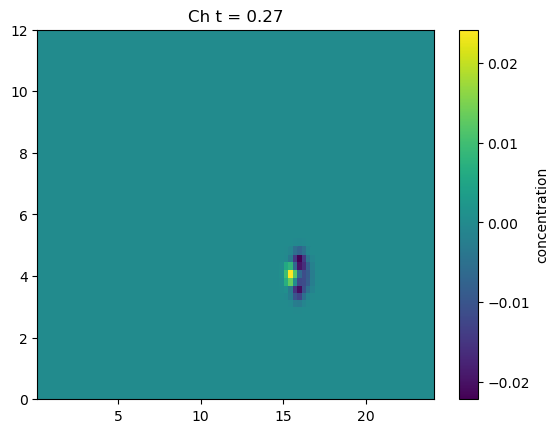

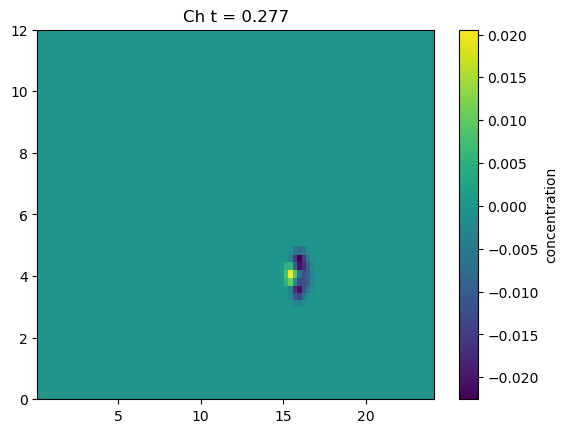

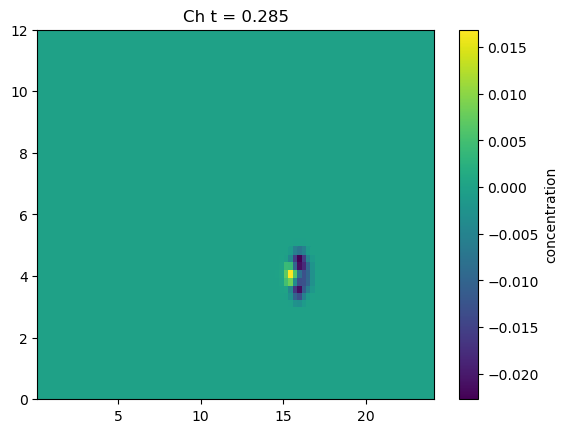

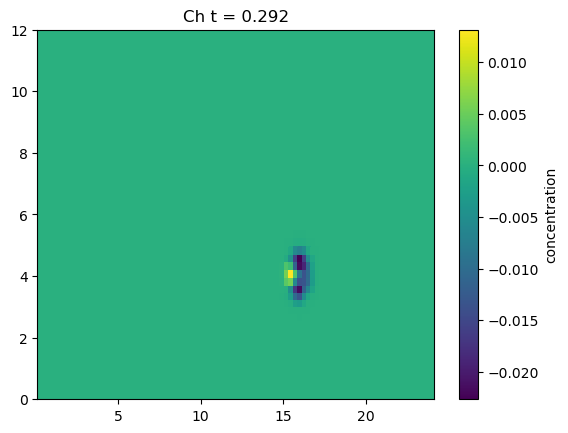

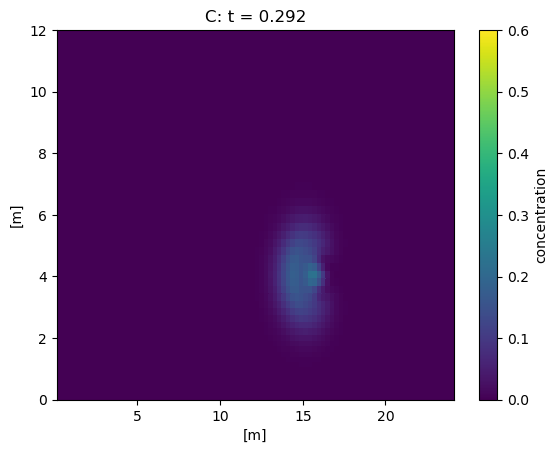

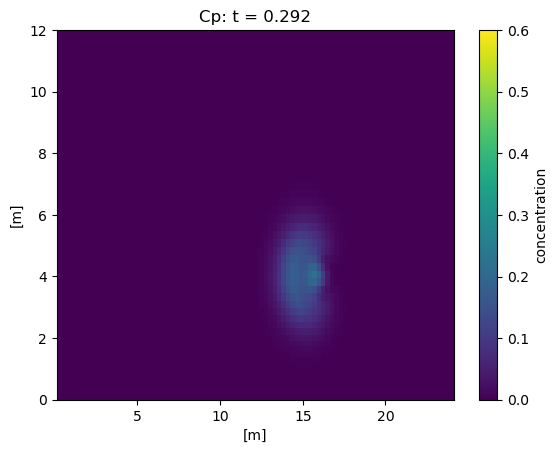

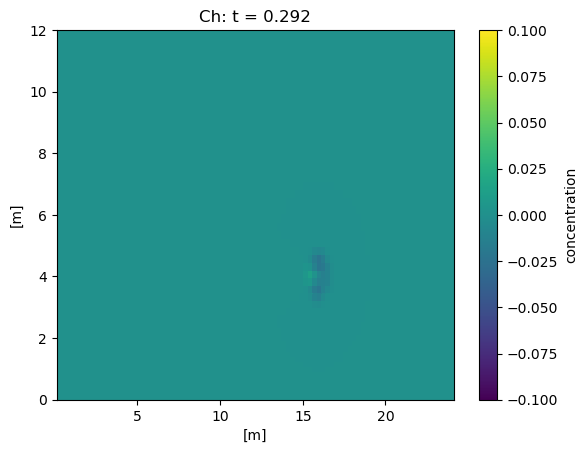

In [28]:
if plots:
    make_plots(timestamp,solution_types, show_figs)
if gifs:
    make_gifs(timestamp,solution_types,interval)